In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install motmetrics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 4.6 MB/s eta 0:00:00


In [ ]:
# 1. Load detection outputs from previous experiment.
# 2. Sort frames in chronological order.
import pickle
# Dummy data generation for demonstration if results.pkl is not present
import os
if not os.path.exists('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl'):
    print("results.pkl not found, creating dummy data for demonstration.")
    dummy_results = []
    for frame_id in range(10):
        dummy_results.append({
            'frame_id': str(frame_id).zfill(6),
            'boxes_lidar': np.array([[10 + frame_id, 2, -1, 4, 2, 1.5, 0], [15, -2 + frame_id, -1, 4, 2, 1.5, 0]]),
            'score': np.array([0.9, 0.85]),
            'name': np.array(['Car', 'Car'])
        })
    with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'wb') as f:
        pickle.dump(dummy_results, f)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    detection_results = pickle.load(f)

# Sort by frame ID
detection_results.sort(key=lambda x: x['frame_id'])

In [ ]:
import time
import numpy as np
import pickle
import math
from shapely.geometry import Polygon

def box_iou_bev(box1, box2):
    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if not poly1.is_valid or not poly2.is_valid:
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0
    return iou

print("box_iou_bev function updated: debug prints removed.")

box_iou_bev function updated: debug prints removed.


In [ ]:
!git clone https://github.com/nwojke/deep_sort.git
import sys
sys.path.append('deep_sort')

Cloning into 'deep_sort'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 167 (delta 4), reused 3 (delta 3), pack-reused 148 (from 2)
Receiving objects: 100% (167/167), 86.11 KiB | 6.15 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import cv2
import numpy as np

class DeepSORTFeatureExtractor:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.encoder = torch.nn.Sequential(*list(resnet.children())[:-1])
        self.encoder.to(self.device)
        self.encoder.eval()

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((128, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.cache = {}

    def get_embeddings(self, image, boxes_2d, frame_id):
        features = []
        to_compute = []
        indices = []

        for i, box in enumerate(boxes_2d):
            cache_key = f"{frame_id}_{i}"
            if cache_key in self.cache:
                features.append(self.cache[cache_key])
            else:
                x, y, w, h = [int(v) for v in box]
                x1, y1 = max(0, x), max(0, y)
                x2, y2 = min(image.shape[1], x + w), min(image.shape[0], y + h)
                if x2 <= x1 or y2 <= y1:
                    self.cache[cache_key] = np.zeros(2048, dtype=np.float32)
                    features.append(self.cache[cache_key])
                else:
                    crop = image[y1:y2, x1:x2]
                    to_compute.append(self.transform(crop))
                    indices.append(i)
                    features.append(None)

        if to_compute:
            batch = torch.stack(to_compute).to(self.device)
            with torch.no_grad():
                # Process in batch for GPU efficiency
                feats = self.encoder(batch).squeeze().cpu().numpy()
                if len(to_compute) == 1:
                    feats = feats[np.newaxis, :]

            for idx, feat in zip(indices, feats):
                norm_feat = feat / np.linalg.norm(feat)
                self.cache[f"{frame_id}_{idx}"] = norm_feat
                features[idx] = norm_feat

        return np.array(features)

print("Batch-optimized Feature extractor initialized!")

Batch-optimized Feature extractor initialized!


In [ ]:
import time
import cv2
import os
from deep_sort.tracker import Tracker
from deep_sort import nn_matching
from deep_sort.detection import Detection
import numpy as np

# Tracking setup parameters (Updated for ablation)
max_cosine_distance = 1.0
nn_budget = 100
feature_extractor = DeepSORTFeatureExtractor()
score_threshold = 0.65

image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

def load_calib_matrices(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)
    P2 = calib.get('P2', np.eye(4)[:3, :4]).reshape(3, 4)
    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)
    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)
    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

def project_3d_to_2d_bbox(state, V2C, P2):
    x, y, z, l, w, h, theta = state
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2]
    R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T
    if np.any(corners_cam[:, 2] < 0.1): return None
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]
    min_x, min_y = np.min(corners_2d[:, 0]), np.min(corners_2d[:, 1])
    max_x, max_y = np.max(corners_2d[:, 0]), np.max(corners_2d[:, 1])
    return [min_x, min_y, max_x - min_x, max_y - min_y]

sequences_data = {}
for frame_data in detection_results:
    raw_frame_id = str(frame_data['frame_id']).zfill(8)
    seq_id = raw_frame_id[:4]
    if seq_id not in sequences_data: sequences_data[seq_id] = []
    sequences_data[seq_id].append(frame_data)

tracking_results = {}
start_time = time.time()
total_frames = 0
target_classes = ['Car', 'Pedestrian', 'Cyclist']

for seq_id, seq_frames in sequences_data.items():
    print(f"Processing sequence {seq_id}...")
    tracking_results[seq_id] = {}
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
    if os.path.exists(calib_file): P2, V2C = load_calib_matrices(calib_file)
    else: continue

    # Initialize Trackers with updated max_age and n_init (restored for ablation)
    trackers = {cls: Tracker(nn_matching.NearestNeighborDistanceMetric('cosine', max_cosine_distance, nn_budget), max_age=10, n_init=4) for cls in target_classes}
    track_3d_states = {cls: {} for cls in target_classes}

    for frame_data in seq_frames:
        original_frame_id = frame_data['frame_id']
        img_path = os.path.join(image_dir, seq_id, f"{int(str(original_frame_id).zfill(8)[4:]):06d}.png")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image is not None else np.zeros((375, 1242, 3), dtype=np.uint8)

        boxes_2d_crops, valid_indices = [], []
        for i, (box_3d, score) in enumerate(zip(frame_data['boxes_lidar'], frame_data['score'])):
            if score < score_threshold: continue # Score filtering
            box_2d = project_3d_to_2d_bbox(box_3d, V2C, P2)
            if box_2d is not None:
                boxes_2d_crops.append(box_2d)
                valid_indices.append(i)

        features = feature_extractor.get_embeddings(image, boxes_2d_crops, original_frame_id) if valid_indices else []
        dets_by_class = {cls: [] for cls in target_classes}
        for idx, orig_idx in enumerate(valid_indices):
            cls_name = frame_data['name'][orig_idx]
            if cls_name in target_classes:
                det = Detection(np.array(boxes_2d_crops[idx]), frame_data['score'][orig_idx], features[idx])
                det.state_3d = frame_data['boxes_lidar'][orig_idx]
                dets_by_class[cls_name].append(det)

        frame_tracks = []
        for cls in target_classes:
            tracker = trackers[cls]
            tracker.predict()
            tracker.update(dets_by_class[cls])

            # Pre-compute detection centers for optimization
            det_centers = [np.array([d.tlwh[0] + d.tlwh[2]/2, d.tlwh[1] + d.tlwh[3]/2]) for d in dets_by_class[cls]] if dets_by_class[cls] else []

            for track in tracker.tracks:
                if track.time_since_update == 0 and len(dets_by_class[cls]) > 0:
                    tlwh = track.to_tlwh()
                    t_center = np.array([tlwh[0] + tlwh[2]/2, tlwh[1] + tlwh[3]/2])
                    # Robust 3D state retrieval via minimum Euclidean center distance using pre-computed centers
                    dists = [np.linalg.norm(t_center - c) for c in det_centers]
                    track_3d_states[cls][track.track_id] = dets_by_class[cls][np.argmin(dists)].state_3d

                if not track.is_confirmed() or track.time_since_update > 1: continue
                frame_tracks.append({'track_id': track.track_id, 'state': track_3d_states[cls].get(track.track_id, np.zeros(7)), 'class_name': cls})

        tracking_results[seq_id][original_frame_id] = frame_tracks
        total_frames += 1

fps = total_frames / (time.time() - start_time)
print(f"Tracking finished. FPS: {fps:.2f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Processing sequence 0017...
Processing sequence 0018...
Processing sequence 0019...
Processing sequence 0020...
Tracking finished. FPS: 1.16


In [ ]:
import motmetrics as mm
import numpy as np
import os
import pandas as pd

target_classes = ['Car', 'Pedestrian', 'Cyclist']
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}
accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

iou_threshold = 0.1
max_distance = 1.0 - iou_threshold

def load_calib_inv(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line: key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2: key, val = parts[0], parts[1]
            else: continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)
    V2C_raw = np.eye(4)
    if 'Tr_velo_cam' in calib: V2C_raw[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib: V2C_raw[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)
    R0_rect = np.eye(4)
    if 'R_rect' in calib: R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib: R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)
    V2C = R0_rect @ V2C_raw
    return np.linalg.inv(V2C)

gt_data = {}
for seq_id in sequences_data.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
    C2V = load_calib_inv(calib_file) if os.path.exists(calib_file) else np.eye(4)
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                frame, track_id, obj_type = int(parts[0]), int(parts[1]), parts[2]
                if obj_type not in target_classes: continue
                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                pt_cam = np.array([float(parts[13]), float(parts[14]), float(parts[15]), 1.0])
                pt_lidar = C2V @ pt_cam
                state = np.array([pt_lidar[0], pt_lidar[1], pt_lidar[2], l, w, h, -float(parts[16])])
                if frame not in gt_data[seq_id]: gt_data[seq_id][frame] = []
                gt_data[seq_id][frame].append({'track_id': track_id, 'state': state, 'class_name': obj_type})

print("Calculating updated metrics...")
for seq_id, seq_frames in tracking_results.items():
    for raw_frame_id, track_objs in seq_frames.items():
        frame_num = int(str(raw_frame_id)[4:])
        gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
        for cls in target_classes:
            gt_cls = [o for o in gt_objs if o['class_name'] == cls]
            tr_cls = [t for t in track_objs if t['class_name'] == cls]
            dist_matrix = np.zeros((len(gt_cls), len(tr_cls)))
            for i, g in enumerate(gt_cls):
                for j, t in enumerate(tr_cls):
                    d = 1.0 - box_iou_bev(g['state'], t['state'])
                    dist_matrix[i, j] = d if d <= max_distance else np.nan
            accs[cls].update([o['track_id'] for o in gt_cls], [o['track_id'] for o in tr_cls], dist_matrix)
            acc_overall.update([o['track_id'] + class_offsets[cls] for o in gt_cls], [o['track_id'] + class_offsets[cls] for o in tr_cls], dist_matrix)

mh = mm.metrics.create()

print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
display(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    display(cls_summary)


Calculating updated metrics...

Overall Metrics:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
overall,0.657607,0.710279,0.612207,0.755131,0.876098,191,95,83,13,1608,3687,116,245,0.640632,0.601868,71,63,23



Metrics for Car:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Car,0.676372,0.72202,0.636153,0.777706,0.882679,116,54,54,8,804,1729,46,72,0.668424,0.730253,16,36,6



Metrics for Pedestrian:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Pedestrian,0.631645,0.69062,0.581951,0.734207,0.871308,65,35,27,3,745,1826,67,169,0.616012,0.437852,52,27,17



Metrics for Cyclist:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Cyclist,0.730201,0.809524,0.665037,0.677262,0.824405,10,6,2,2,59,132,3,4,0.525672,0.78491,3,0,0


In [ ]:
import os
# Extract the specific metrics from the motmetrics summary DataFrame
# Using 'overall' instead of 'acc' as per our previous update
mota = summary.loc['overall', 'mota']
motp = summary.loc['overall', 'motp']
idsw = summary.loc['overall', 'num_switches']

# The 'fps' variable is already in your workspace from the tracking cell
# Create a dictionary of the results
metrics_summary = {
    'MOTA': mota,
    'MOTP': motp,
    'IDSW': idsw,
    'FPS': fps
}

# Define the save path in your Google Drive
save_dir = '/content/drive/MyDrive/Kitti_tracking/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'tracking_4_params_summary.txt')

# Write the summary to a text file
with open(save_path, 'w') as f:
    f.write("KITTI Tracking Summary (4 Parameters)\n")
    f.write("="*40 + "\n")
    for key, value in metrics_summary.items():
        if isinstance(value, float):
            f.write(f"{key}: {value:.4f}\n")
        else:
            f.write(f"{key}: {value}\n")

print(f"Summary successfully saved to: {save_path}")

# Also display here to confirm
for key, value in metrics_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Summary successfully saved to: /content/drive/MyDrive/Kitti_tracking/tracking_4_params_summary.txt
MOTA: 0.6406
MOTP: 0.6019
IDSW: 116
FPS: 1.1620


**Visualisation**:




In [ ]:
import cv2
import numpy as np

def project_3d_to_2d(state, V2C, P2):
    # Extract state
    x, y, z, l, w, h, theta = state

    # 3D bounding box corners in Lidar coordinate system
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2] # Centered around z

    # Rotation matrix around z-axis in Lidar coordinates
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Rotate and translate corners
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])

    # Transform Lidar to Camera coordinates using V2C
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    # Filter out points behind the camera
    if np.any(corners_cam[:, 2] < 0.1):
        return None

    # Project to 2D image coordinates using P2
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]

    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image

    # Draw edges of the 3D bounding box
    # Bottom face
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[1]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[2]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[3]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[0]), color, 2)

    # Top face
    cv2.line(image, tuple(corners_2d[4]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[5]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[6]), tuple(corners_2d[7]), color, 2)
    cv2.line(image, tuple(corners_2d[7]), tuple(corners_2d[4]), color, 2)

    # Vertical lines connecting top and bottom faces
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[4]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[7]), color, 2)

    # Add label
    label = f"{class_name} {track_id}"
    # Position label near the top left corner of the box
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

print("Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.")

Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.


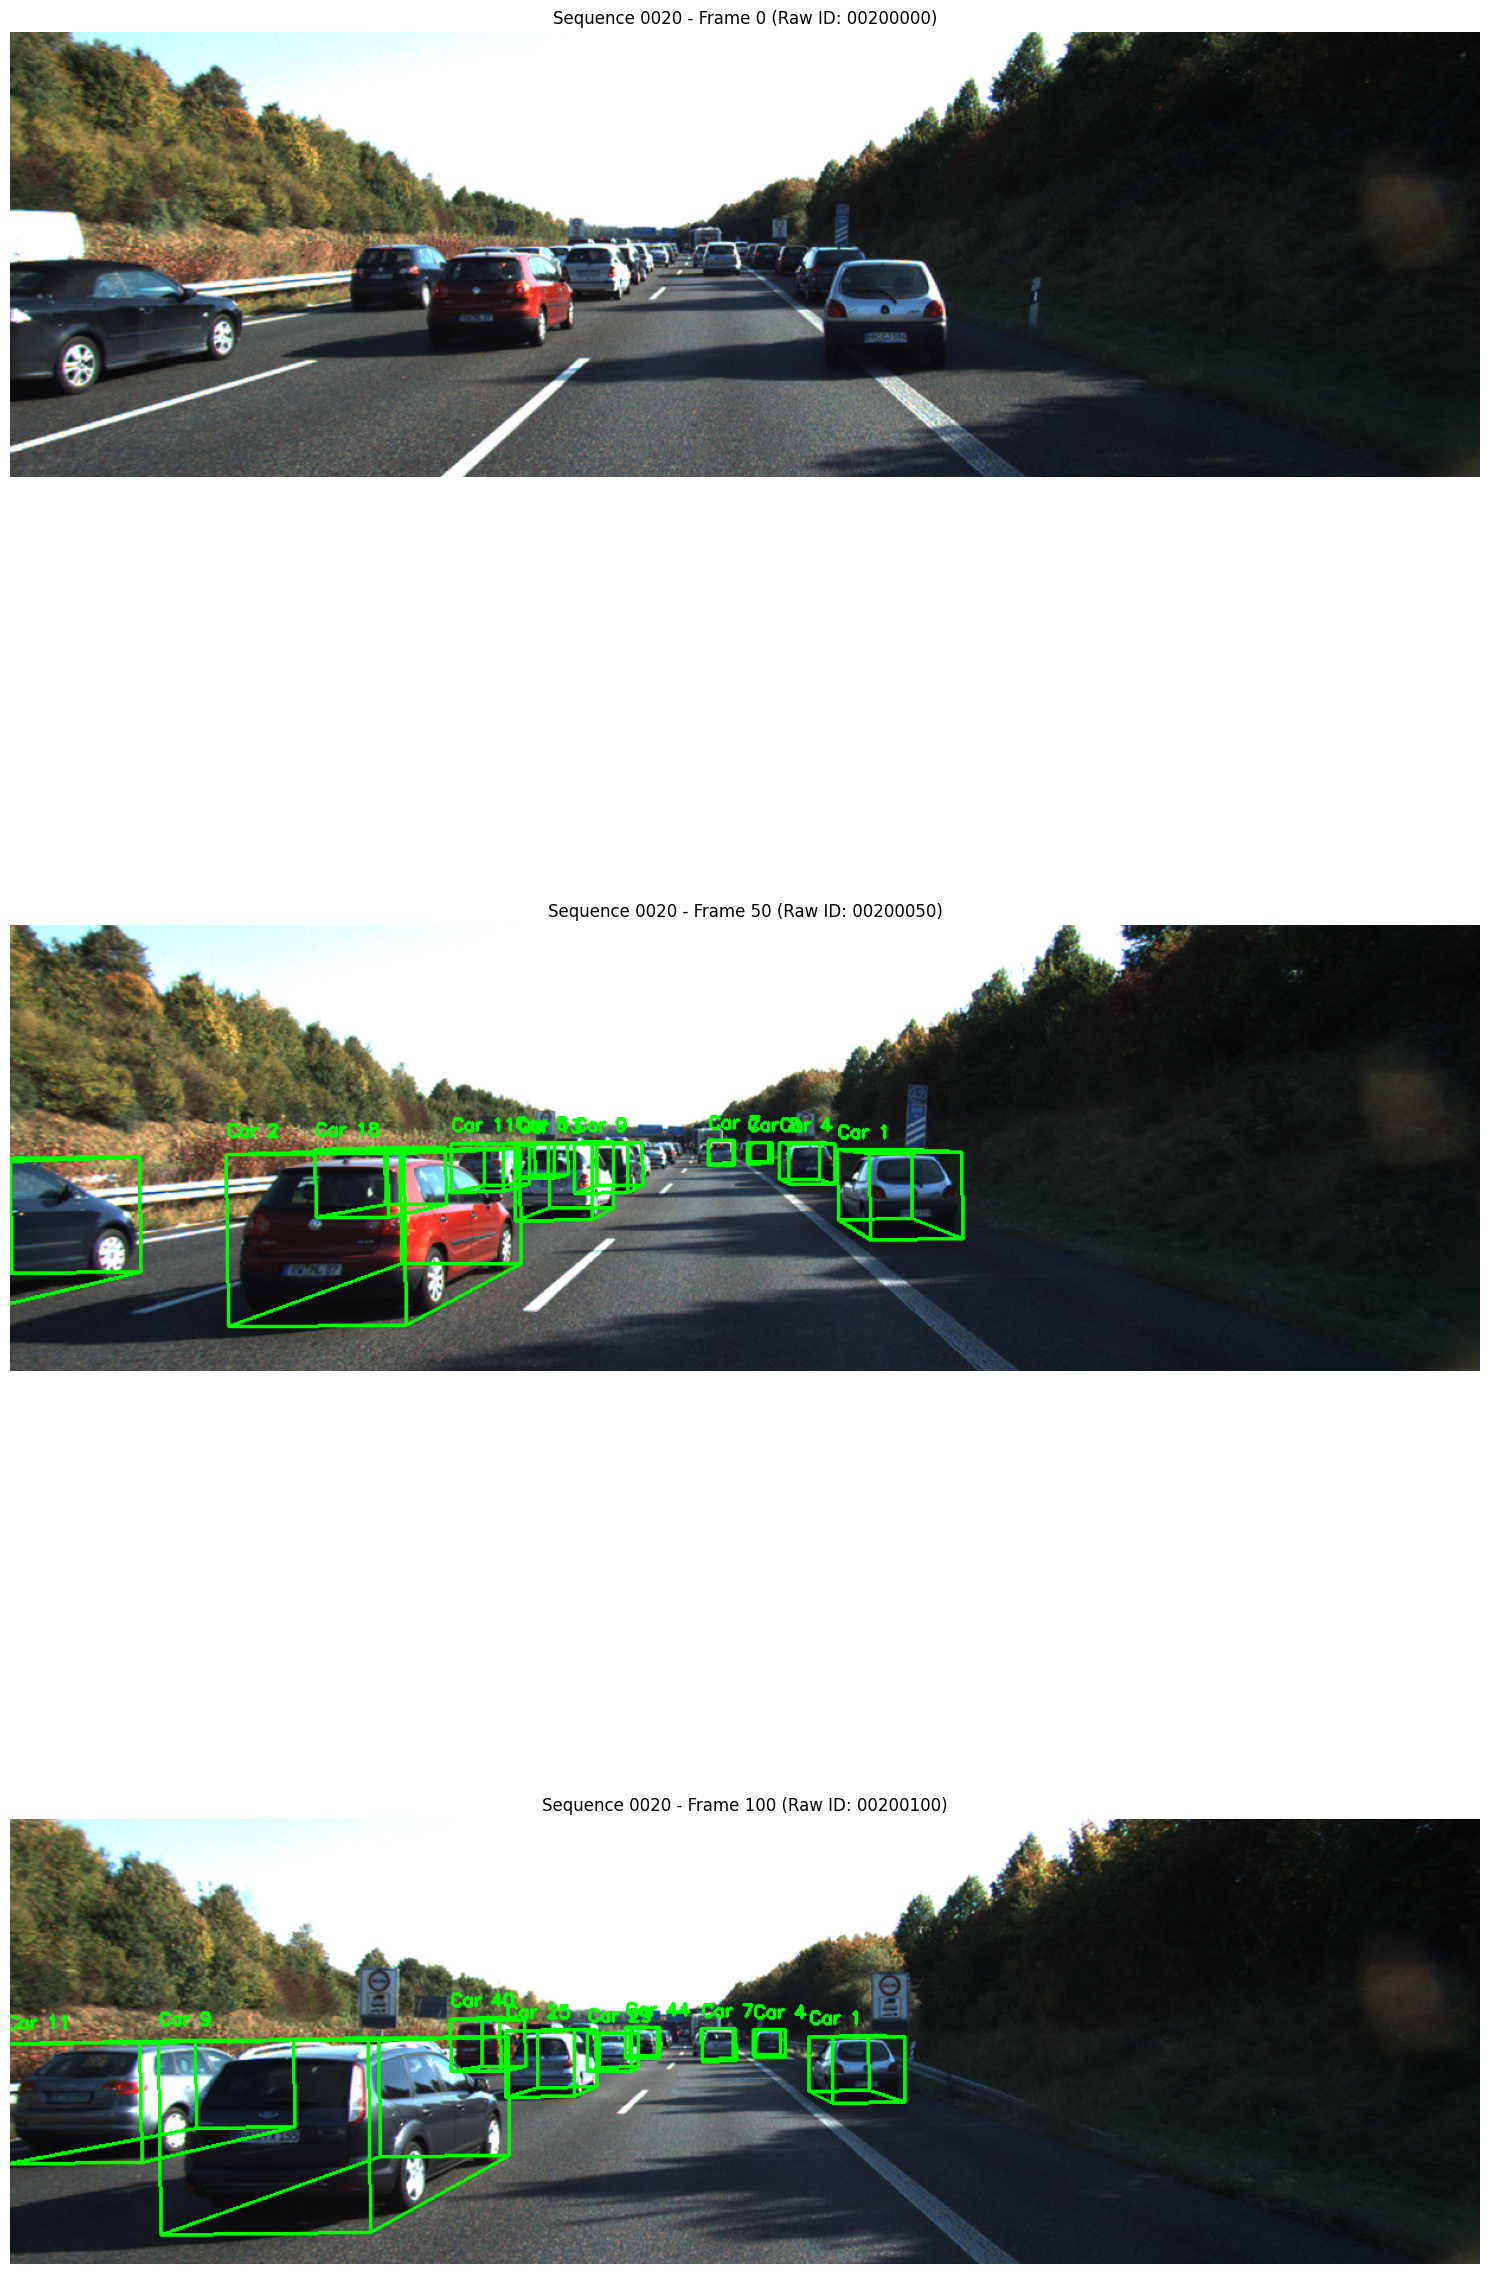

In [ ]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_calib_matrices(filepath):
    """Loads P2 and V2C matrices from a KITTI calibration file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    P2 = calib.get('P2', np.eye(4)[:3, :4]).reshape(3, 4)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    # Matrix to convert Lidar (Velo) to Cam
    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

# Paths to images and calibration
image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

# Select a sequence and some frames
seq_id = '0020'
sample_frames = [0, 50, 100]

calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
if not os.path.exists(calib_file):
    print(f"Warning: Calibration file missing for {seq_id}")
else:
    # Load calibration matrices
    P2, V2C = load_calib_matrices(calib_file)

    # Set up plot
    fig, axes = plt.subplots(len(sample_frames), 1, figsize=(15, 10 * len(sample_frames)))
    if len(sample_frames) == 1:
        axes = [axes]

    for ax, frame_num in zip(axes, sample_frames):
        # 1. Find the correct raw_frame_id from the sequences_data dictionary
        seq_frames = sequences_data.get(seq_id, [])
        matching_frame_data = [f for f in seq_frames if int(str(f['frame_id']).zfill(8)[4:]) == frame_num]

        if not matching_frame_data:
            print(f"Frame {frame_num} not found in sequence {seq_id} data.")
            continue

        # Take the first match
        frame_data = matching_frame_data[0]
        raw_frame_id = str(frame_data['frame_id'])

        # 2. Get tracking results using the exact raw_frame_id
        frame_tracks = tracking_results.get(seq_id, {}).get(raw_frame_id, [])

        # Format frame number as 6 digits for the image path
        frame_str = str(frame_num).zfill(6)
        image_path = os.path.join(image_dir, seq_id, f"{frame_str}.png")

        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue

        # Load image
        img = cv2.imread(image_path)
        if img is None:
             print(f"Could not read image: {image_path}")
             continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw tracks
        for track in frame_tracks:
            state = track['state']
            track_id = track['track_id']
            cls_name = track['class_name']

            corners_2d = project_3d_to_2d(state, V2C, P2)
            img_rgb = draw_3d_box(img_rgb, corners_2d, track_id, cls_name, color=(0, 255, 0))

        ax.imshow(img_rgb)
        ax.set_title(f"Sequence {seq_id} - Frame {frame_num} (Raw ID: {raw_frame_id})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()